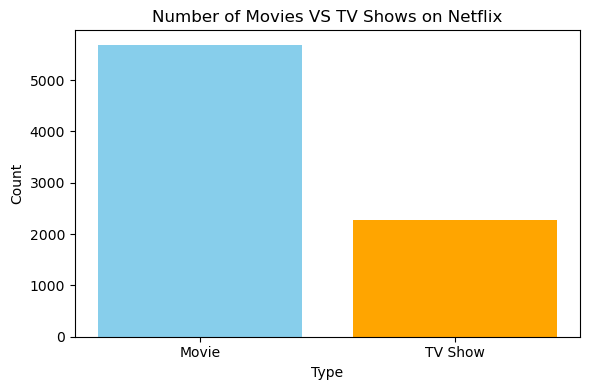

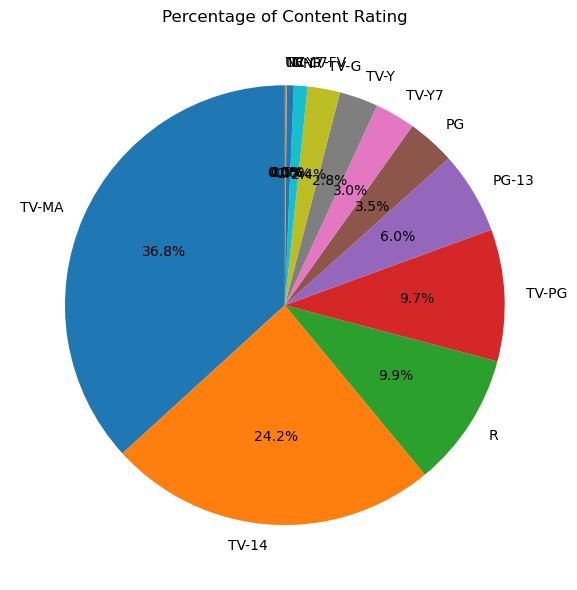

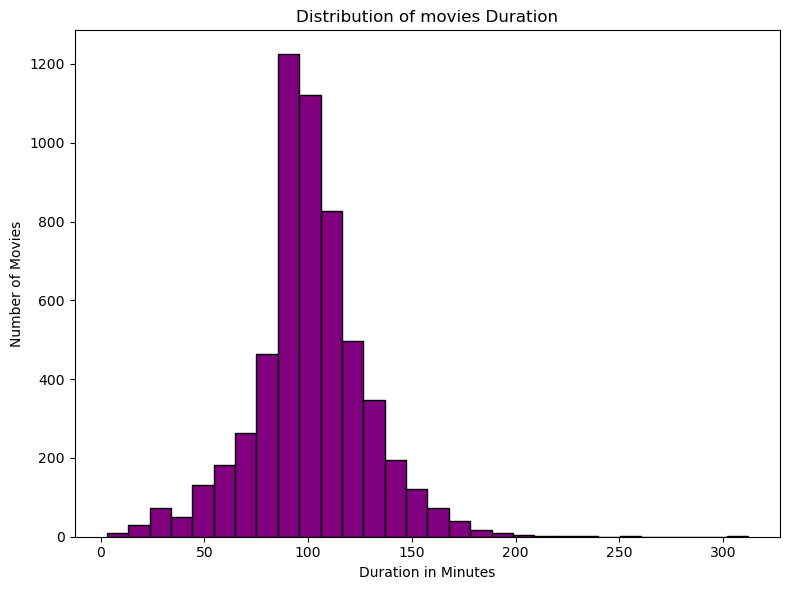

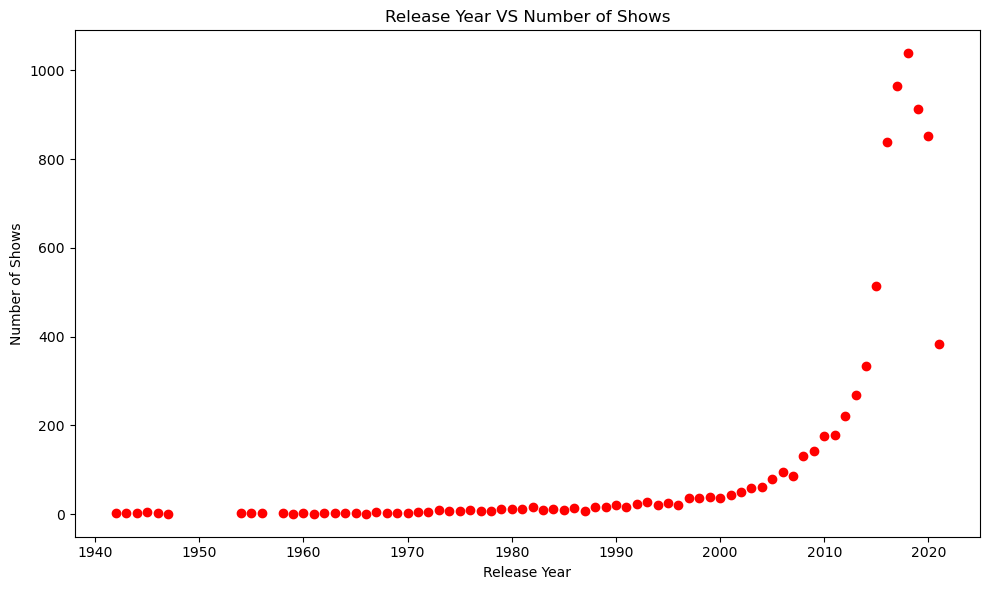

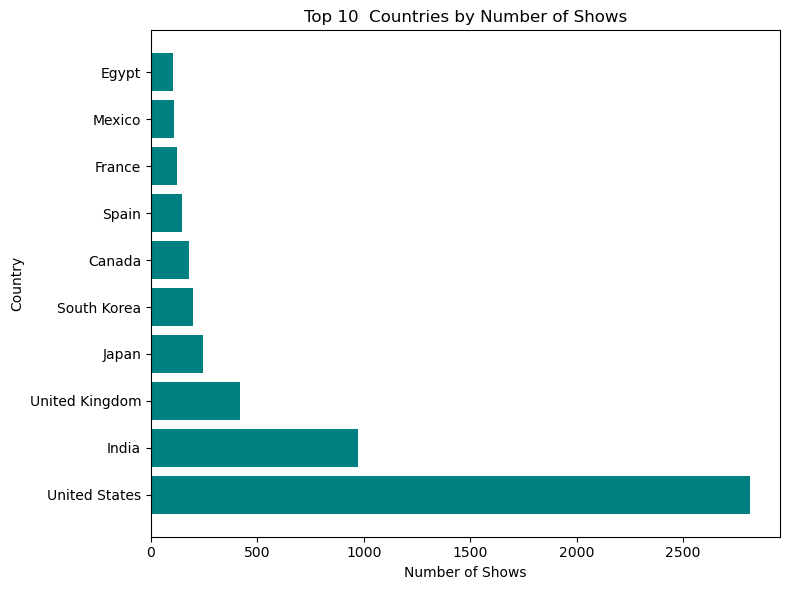

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('netflix_titles.csv')

df=df.dropna(subset=['type','release_year','rating','country','duration'])

type_counts=df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue','orange'])
plt.title("Number of Movies VS TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

rating_counts=df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts,labels=rating_counts.index,autopct='%1.1f%%', startangle=90)
plt.title("Percentage of Content Rating")
plt.tight_layout()
plt.savefig('Content_rating.png')
plt.show()


movie_df=df[df['type']=='Movie'].copy()
movie_df['duration_int']=movie_df['duration'].str.replace('min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color='purple',edgecolor='black')
plt.title("Distribution of movies Duration")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig('Distribution_of_movies_duration.png')
plt.show()


release_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index,release_counts.values,color='red')
plt.title("Release Year VS Number of Shows")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.savefig('Release_year_scatterplot.png')
plt.show()


country_counts=df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index,country_counts.values, color='teal')
plt.title("Top 10  Countries by Number of Shows")
plt.xlabel("Number of Shows")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig('Top10_countries.png')
plt.show()


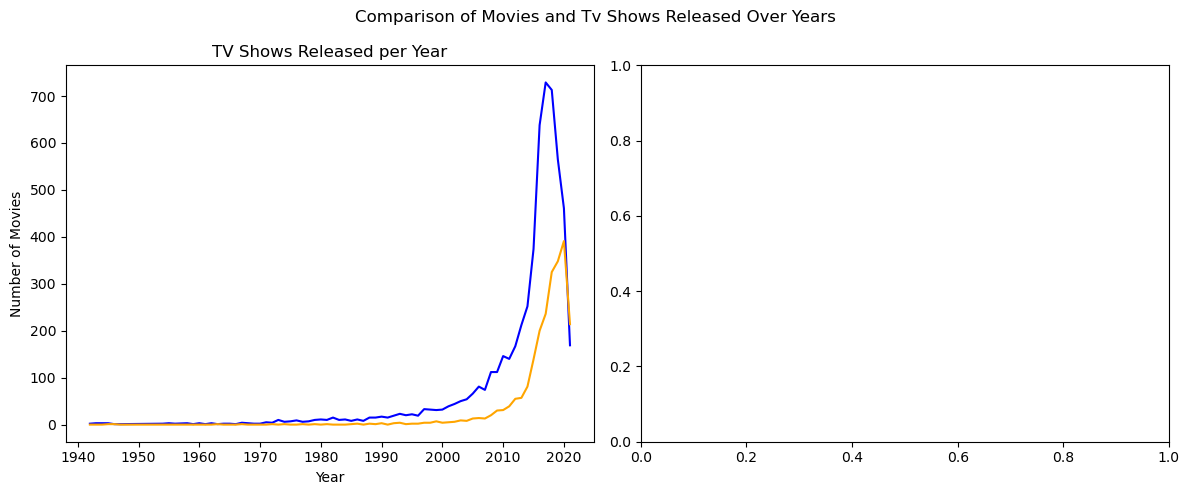

In [19]:
contentbyyear=df.groupby(['release_year','type']).size().unstack().fillna(0)
fig,ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(contentbyyear.index,contentbyyear['Movie'], color='blue')
ax[0].set_title('Movies Released by Year')
ax[0].set_xlabel("Year")
ax[0].set_ylabel('Number of Movies')

#tv shows
ax[0].plot(contentbyyear.index,contentbyyear['TV Show'], color='orange')
ax[0].set_title('TV Shows Released per Year')
ax[0].set_xlabel("Year")
ax[0].set_ylabel('Number of Movies')

fig.suptitle('Comparison of Movies and Tv Shows Released Over Years')
plt.tight_layout()

plt.savefig('movies_tvshows_comparison.png')
plt.show()



